In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.ensemble import AdaBoostClassifier
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../Dataset/Travel.csv")
df.head()


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [3]:
df.drop(columns=['CustomerID'], inplace=True)


In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols


(Index(['ProdTaken', 'Age', 'CityTier', 'DurationOfPitch',
        'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar',
        'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
        'NumberOfChildrenVisiting', 'MonthlyIncome'],
       dtype='object'),
 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
        'MaritalStatus', 'Designation'],
       dtype='object'))

In [5]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()


/var/folders/pq/b78qq0pn4c52hb6z8g239wlr0000gn/T/ipykernel_73533/3259374234.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/var/folders/pq/b78qq0pn4c52hb6z8g239wlr0000gn/T/ipykernel_73533/3259374234.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [6]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,1,3,6.0,2,1,3,3.0,1,3.0,2,1.0,1,2,1,0.0,2,20993.0
1,0,49.0,0,1,14.0,2,2,3,4.0,1,4.0,0,2.0,0,3,1,2.0,2,20130.0
2,1,37.0,1,1,8.0,0,2,3,4.0,0,3.0,2,7.0,1,3,0,0.0,1,17090.0
3,0,33.0,0,1,9.0,2,1,2,3.0,0,3.0,0,2.0,1,5,1,1.0,1,17909.0
4,0,36.0,1,1,8.0,3,2,2,3.0,0,4.0,0,1.0,0,5,1,0.0,1,18468.0


In [7]:
X = df.drop(columns=['ProdTaken'])
y = df['ProdTaken']

X.shape, y.shape


((4888, 18), (4888,))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [9]:
ada_clf = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

ada_clf.fit(X_train, y_train)


/Users/harshraj/Desktop/Ml_miniProjects/.conda/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(learning_rate=0.05, n_estimators=300, random_state=42)

In [10]:
y_pred = ada_clf.predict(X_test)
y_pred_proba = ada_clf.predict_proba(X_test)[:, 1]


In [11]:
accuracy_score(y_test, y_pred)


0.83640081799591

In [12]:
confusion_matrix(y_test, y_pred)


array([[788,   6],
       [154,  30]])

In [13]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.99      0.91       794
           1       0.83      0.16      0.27       184

    accuracy                           0.84       978
   macro avg       0.83      0.58      0.59       978
weighted avg       0.84      0.84      0.79       978



In [14]:
roc_auc_score(y_test, y_pred_proba)


0.7675877505202059

In [15]:
feature_importance = pd.Series(
    ada_clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


Passport                 0.133333
NumberOfFollowups        0.113333
ProductPitched           0.110000
CityTier                 0.100000
Age                      0.086667
DurationOfPitch          0.086667
MaritalStatus            0.083333
PreferredPropertyStar    0.080000
NumberOfTrips            0.043333
MonthlyIncome            0.040000
dtype: float64

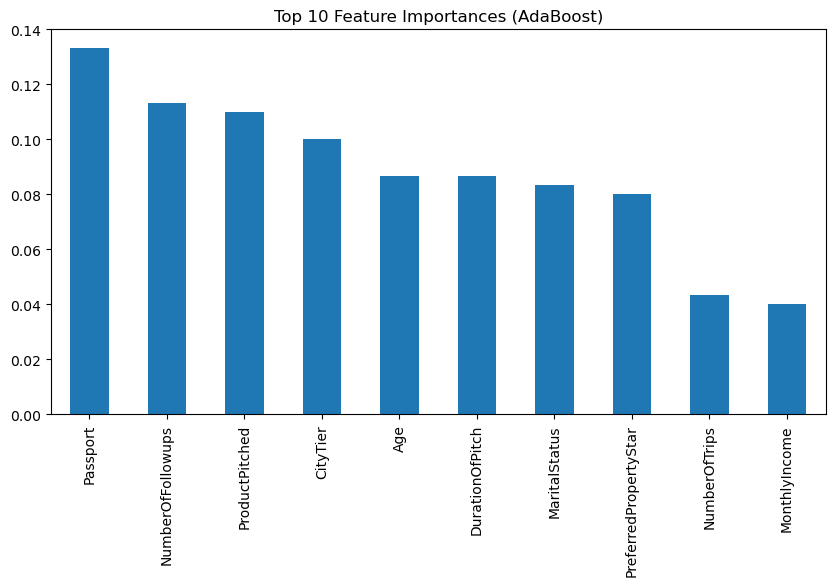

In [16]:
feature_importance.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Feature Importances (AdaBoost)'
)
plt.show()


In [17]:
sample = X_test.iloc[0].values.reshape(1, -1)

prediction = ada_clf.predict(sample)
probability = ada_clf.predict_proba(sample)

prediction, probability


/Users/harshraj/Desktop/Ml_miniProjects/.conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/Users/harshraj/Desktop/Ml_miniProjects/.conda/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


(array([0]), array([[0.50982575, 0.49017425]]))